<a href="https://colab.research.google.com/github/mohammedh897/car-insurance-claim-prediction/blob/main/Project_2_Part_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Insurance Claim Prediction — Part 2
## Feature Engineering, Feature Selection & Permutation Importance

**Dataset:** Car Insurance Data (Kaggle – sagnik1511)  
**Target:** `OUTCOME` — whether a customer filed an insurance claim (1 = Yes, 0 = No)  
**Goal:** Apply feature engineering to the Part 1 pipeline, select the best features, and compare model performance.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, accuracy_score)

print("All libraries loaded ✓")


All libraries loaded ✓


---
## 1. Reproduce Part 1 Pipeline

We re-run the exact same preprocessing and train/test split from Part 1 so all comparisons are apples-to-apples.


In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1TXllin1EyO3hB88yV8J4MElTpXaiFY3K')

# POSTAL_CODE is a nominal identifier, not a number
df['POSTAL_CODE'] = df['POSTAL_CODE'].astype(str)

print(f"Shape: {df.shape}")
df.head()


Shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
X = df.drop(columns=['OUTCOME', 'ID'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train claim rate: {y_train.mean():.2%}  |  Test claim rate: {y_test.mean():.2%}")


Train: 8,000 rows  |  Test: 2,000 rows
Train claim rate: 31.32%  |  Test claim rate: 31.35%


In [ ]:
# ── Feature lists (same as Part 1) ──────────────────────────────────────────
numeric_features  = ['CREDIT_SCORE', 'ANNUAL_MILEAGE',
                     'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS',
                     'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']

ordinal_features   = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_categories = [
    ['16-25', '26-39', '40-64', '65+'],
    ['0-9y', '10-19y', '20-29y', '30y+'],
    ['none', 'high school', 'university'],
    ['poverty', 'working class', 'middle class', 'upper class'],
]

nominal_features = ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE', 'POSTAL_CODE']

# ── Pipelines ────────────────────────────────────────────────────────────────
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False,
                              handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num',     numeric_pipe,  numeric_features),
    ('ordinal', ordinal_pipe,  ordinal_features),
    ('nominal', nominal_pipe,  nominal_features),
], remainder='drop')


In [ ]:
# ── Baseline: Tuned Random Forest (Part 1 best model) ───────────────────────
param_dist_rf = {
    'classifier__n_estimators':      [100, 200, 300, 500],
    'classifier__max_depth':         [None, 5, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 2, 4],
    'classifier__max_features':      ['sqrt', 'log2'],
}

rf_baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced')),
])

baseline_search = RandomizedSearchCV(
    rf_baseline_pipeline,
    param_dist_rf,
    n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0,
)

baseline_search.fit(X_train, y_train)
best_baseline = baseline_search.best_estimator_

y_pred_base  = best_baseline.predict(X_test)
y_proba_base = best_baseline.predict_proba(X_test)[:, 1]
auc_base     = roc_auc_score(y_test, y_proba_base)
acc_base     = accuracy_score(y_test, y_pred_base)

print("── Part 1 Baseline (Tuned Random Forest) ──")
print(f"  ROC-AUC : {auc_base:.4f}")
print(f"  Accuracy: {acc_base:.4f}")
print(classification_report(y_test, y_pred_base, target_names=['No Claim', 'Claimed']))


── Part 1 Baseline (Tuned Random Forest) ──
  ROC-AUC : 0.8988
  Accuracy: 0.8330
              precision    recall  f1-score   support

    No Claim       0.92      0.83      0.87      1373
     Claimed       0.70      0.83      0.76       627

    accuracy                           0.83      2000
   macro avg       0.81      0.83      0.81      2000
weighted avg       0.85      0.83      0.84      2000



---
## 2. Feature Engineering

We apply **two complementary engineering strategies** and then combine them with the original preprocessed features:

| Method | What it adds |
|--------|-------------|
| **PCA (3 components)** | Captures global variance structure across all features |
| **K-Means cluster label** | Captures which "risk segment" a customer belongs to |

**Important:** Both PCA and K-Means are **fit only on training data** and then applied to the test set to prevent data leakage.


In [ ]:
# Fit the Part 1 preprocessor on training data
preprocessor.fit(X_train, y_train)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names after preprocessing
ohe_names = (preprocessor.named_transformers_['nominal']
             .named_steps['encoder']
             .get_feature_names_out(nominal_features).tolist())

all_feature_names = numeric_features + ordinal_features + ohe_names

print(f"Preprocessed feature matrix — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"Total features after preprocessing: {len(all_feature_names)}")


Preprocessed feature matrix — Train: (8000, 19), Test: (2000, 19)
Total features after preprocessing: 19


### 2a. PCA – 3 Principal Components

Explained variance per component: [0.2352 0.0913 0.0748]
Total variance explained by 3 PCs: 0.401


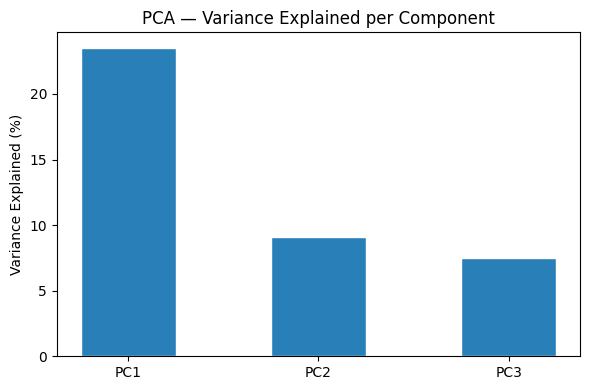

In [ ]:
# Scale first (PCA is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)   # fit on train only
X_test_scaled  = scaler.transform(X_test_proc)

# Fit PCA on training data only
pca = PCA(n_components=3, random_state=42)
pca.fit(X_train_scaled)

print("Explained variance per component:", np.round(pca.explained_variance_ratio_, 4))
print(f"Total variance explained by 3 PCs: {pca.explained_variance_ratio_.sum():.3f}")

pca_train = pca.transform(X_train_scaled)
pca_test  = pca.transform(X_test_scaled)

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['PC1', 'PC2', 'PC3'],
       pca.explained_variance_ratio_ * 100,
       color='#2980b9', edgecolor='white', width=0.5)
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA — Variance Explained per Component')
plt.tight_layout()
plt.show()


### 2b. K-Means Clustering

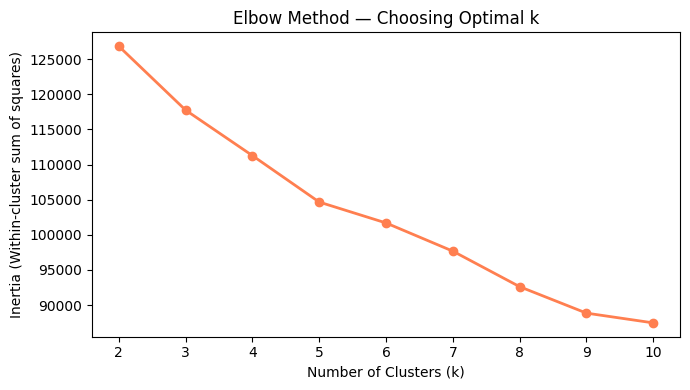

In [ ]:
# Elbow method — fit on scaled training data only
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o', color='coral', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method — Choosing Optimal k')
plt.xticks(K_range)
plt.tight_layout()
plt.show()


In [ ]:
# Select k = 4 (adjust after inspecting the elbow plot above)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
kmeans.fit(X_train_scaled)   # fit on training data ONLY

cluster_train = kmeans.predict(X_train_scaled).reshape(-1, 1)
cluster_test  = kmeans.predict(X_test_scaled).reshape(-1, 1)

print("Train cluster distribution:", dict(zip(*np.unique(cluster_train, return_counts=True))))
print("Test  cluster distribution:", dict(zip(*np.unique(cluster_test,  return_counts=True))))


Train cluster distribution: {np.int32(0): np.int64(3054), np.int32(1): np.int64(371), np.int32(2): np.int64(1705), np.int32(3): np.int64(2870)}
Test  cluster distribution: {np.int32(0): np.int64(776), np.int32(1): np.int64(99), np.int32(2): np.int64(422), np.int32(3): np.int64(703)}


### 2c. Combine Original + PCA + Cluster Features

In [ ]:
# Concatenate: original preprocessed | PC1 PC2 PC3 | Cluster
X_train_eng = np.hstack([X_train_proc, pca_train, cluster_train])
X_test_eng  = np.hstack([X_test_proc,  pca_test,  cluster_test])

engineered_names = all_feature_names + ['PC1', 'PC2', 'PC3', 'Cluster']

print(f"Engineered feature matrix — Train: {X_train_eng.shape}, Test: {X_test_eng.shape}")
print(f"3 PCA columns + 1 Cluster column added → {X_train_eng.shape[1]} total features")


Engineered feature matrix — Train: (8000, 23), Test: (2000, 23)
3 PCA columns + 1 Cluster column added → 23 total features


---
## 3. Model Evaluation With Engineered Features

We train the same Random Forest (with the same hyperparameter search) on the **engineered** feature set and compare it directly to the Part 1 baseline.


In [ ]:
param_dist_rf2 = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_eng = RandomForestClassifier(random_state=42, class_weight='balanced')
search_eng = RandomizedSearchCV(
    rf_eng, param_dist_rf2,
    n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0,
)

search_eng.fit(X_train_eng, y_train)
best_eng = search_eng.best_estimator_

y_pred_eng  = best_eng.predict(X_test_eng)
y_proba_eng = best_eng.predict_proba(X_test_eng)[:, 1]
auc_eng     = roc_auc_score(y_test, y_proba_eng)
acc_eng     = accuracy_score(y_test, y_pred_eng)

print("── Engineered Features — Tuned Random Forest ──")
print(f"  ROC-AUC : {auc_eng:.4f}")
print(f"  Accuracy: {acc_eng:.4f}")
print(classification_report(y_test, y_pred_eng, target_names=['No Claim', 'Claimed']))


── Engineered Features — Tuned Random Forest ──
  ROC-AUC : 0.8973
  Accuracy: 0.8315
              precision    recall  f1-score   support

    No Claim       0.90      0.85      0.87      1373
     Claimed       0.70      0.80      0.75       627

    accuracy                           0.83      2000
   macro avg       0.80      0.82      0.81      2000
weighted avg       0.84      0.83      0.83      2000



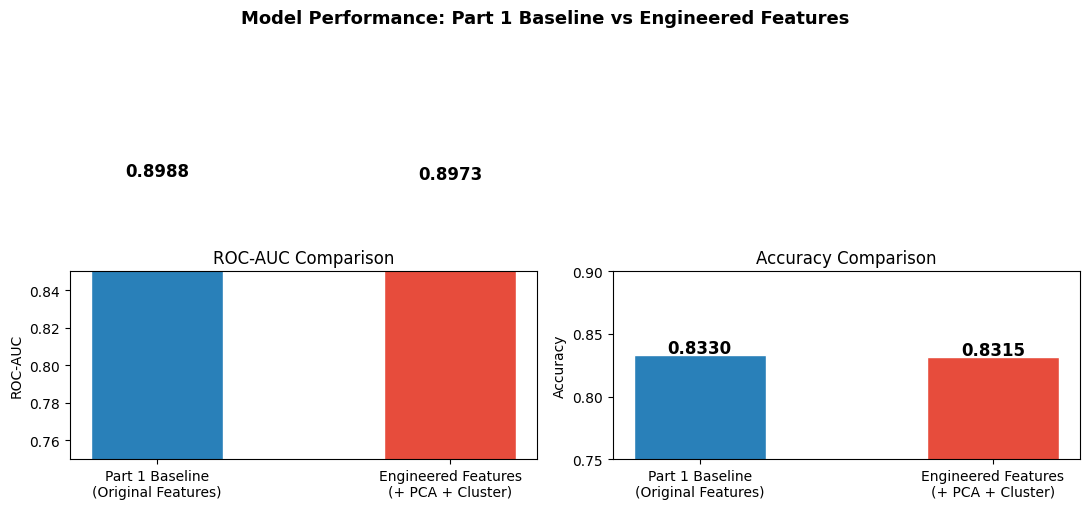

In [ ]:
models_compared = ['Part 1 Baseline\n(Original Features)',
                   'Engineered Features\n(+ PCA + Cluster)']
aucs = [auc_base, auc_eng]
accs = [acc_base, acc_eng]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colors = ['#2980b9', '#e74c3c']

axes[0].bar(models_compared, aucs, color=colors, edgecolor='white', width=0.45)
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.75, 0.85)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('ROC-AUC Comparison')

axes[1].bar(models_compared, accs, color=colors, edgecolor='white', width=0.45)
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0.75, 0.90)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Comparison')

plt.suptitle('Model Performance: Part 1 Baseline vs Engineered Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 4. Feature Selection

We apply **two complementary selection methods** to the engineered feature set:

| Method | Type | Description |
|--------|------|-------------|
| **SelectFromModel (RF importance ≥ mean)** | Embedded | Uses the Random Forest's built-in feature importances to drop low-signal features |
| **RFE with Logistic Regression (top 15)** | Wrapper | Recursively removes the weakest feature, ranking by LR coefficients |


### 4a. Embedded Method — SelectFromModel (Random Forest)

In [ ]:
# Use the already-fitted RF on engineered features as selector
sfm = SelectFromModel(best_eng, threshold='mean', prefit=True)

X_train_sfm = sfm.transform(X_train_eng)
X_test_sfm  = sfm.transform(X_test_eng)

selected_sfm = [engineered_names[i] for i in sfm.get_support(indices=True)]
print(f"SelectFromModel kept {len(selected_sfm)} of {len(engineered_names)} features:")
print(selected_sfm)


SelectFromModel kept 11 of 23 features:
['CREDIT_SCORE', 'SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS', 'VEHICLE_OWNERSHIP', 'AGE', 'DRIVING_EXPERIENCE', 'VEHICLE_YEAR_before 2015', 'PC1', 'PC2', 'PC3', 'Cluster']


In [ ]:
# Evaluate RF on SFM-selected features
rf_sfm = RandomForestClassifier(random_state=42, class_weight='balanced',
                                 **{k.replace('n_estimators','n_estimators'): v
                                    for k, v in search_eng.best_params_.items()})
# rebuild clean params
best_params = search_eng.best_params_
rf_sfm = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42, class_weight='balanced'
)
rf_sfm.fit(X_train_sfm, y_train)

y_pred_sfm  = rf_sfm.predict(X_test_sfm)
y_proba_sfm = rf_sfm.predict_proba(X_test_sfm)[:, 1]
auc_sfm     = roc_auc_score(y_test, y_proba_sfm)
acc_sfm     = accuracy_score(y_test, y_pred_sfm)

print("── SelectFromModel (Embedded) — Random Forest ──")
print(f"  ROC-AUC : {auc_sfm:.4f}")
print(f"  Accuracy: {acc_sfm:.4f}")
print(classification_report(y_test, y_pred_sfm, target_names=['No Claim', 'Claimed']))


── SelectFromModel (Embedded) — Random Forest ──
  ROC-AUC : 0.8750
  Accuracy: 0.8105
              precision    recall  f1-score   support

    No Claim       0.89      0.83      0.86      1373
     Claimed       0.67      0.77      0.72       627

    accuracy                           0.81      2000
   macro avg       0.78      0.80      0.79      2000
weighted avg       0.82      0.81      0.81      2000



### 4b. Wrapper Method — Recursive Feature Elimination (Logistic Regression)

In [ ]:
# Scale engineered features for LR
scaler2 = StandardScaler()
X_train_eng_sc = scaler2.fit_transform(X_train_eng)
X_test_eng_sc  = scaler2.transform(X_test_eng)

lr = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
rfe = RFE(lr, n_features_to_select=15, step=1)
rfe.fit(X_train_eng_sc, y_train)

X_train_rfe = rfe.transform(X_train_eng_sc)
X_test_rfe  = rfe.transform(X_test_eng_sc)

selected_rfe = [engineered_names[i] for i in rfe.get_support(indices=True)]
print(f"RFE kept {len(selected_rfe)} features:")
print(selected_rfe)


RFE kept 15 features:
['ANNUAL_MILEAGE', 'DUIS', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'AGE', 'DRIVING_EXPERIENCE', 'GENDER_male', 'RACE_minority', 'VEHICLE_YEAR_before 2015', 'POSTAL_CODE_21217', 'POSTAL_CODE_32765', 'POSTAL_CODE_92101', 'PC1', 'PC3']


In [ ]:
# Evaluate LR on RFE-selected features
lr_rfe_final = LogisticRegression(max_iter=2000, random_state=42,
                                   class_weight='balanced')
lr_rfe_final.fit(X_train_rfe, y_train)

y_pred_rfe  = lr_rfe_final.predict(X_test_rfe)
y_proba_rfe = lr_rfe_final.predict_proba(X_test_rfe)[:, 1]
auc_rfe     = roc_auc_score(y_test, y_proba_rfe)
acc_rfe     = accuracy_score(y_test, y_pred_rfe)

print("── RFE (Wrapper) — Logistic Regression ──")
print(f"  ROC-AUC : {auc_rfe:.4f}")
print(f"  Accuracy: {acc_rfe:.4f}")
print(classification_report(y_test, y_pred_rfe, target_names=['No Claim', 'Claimed']))


── RFE (Wrapper) — Logistic Regression ──
  ROC-AUC : 0.9158
  Accuracy: 0.8355
              precision    recall  f1-score   support

    No Claim       0.94      0.81      0.87      1373
     Claimed       0.68      0.89      0.77       627

    accuracy                           0.84      2000
   macro avg       0.81      0.85      0.82      2000
weighted avg       0.86      0.84      0.84      2000



### Summary — All Models Compared

In [ ]:
summary = pd.DataFrame({
    'Model': [
        'Part 1 Baseline (RF, original features)',
        'RF — All Engineered Features',
        'RF — SelectFromModel (embedded)',
        'LR — RFE top-15 (wrapper)',
    ],
    'ROC-AUC':  [auc_base, auc_eng, auc_sfm, auc_rfe],
    'Accuracy': [acc_base, acc_eng, acc_sfm, acc_rfe],
})
summary = summary.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


                                  Model  ROC-AUC  Accuracy
              LR — RFE top-15 (wrapper) 0.915841    0.8355
Part 1 Baseline (RF, original features) 0.898750    0.8330
           RF — All Engineered Features 0.897305    0.8315
        RF — SelectFromModel (embedded) 0.874980    0.8105


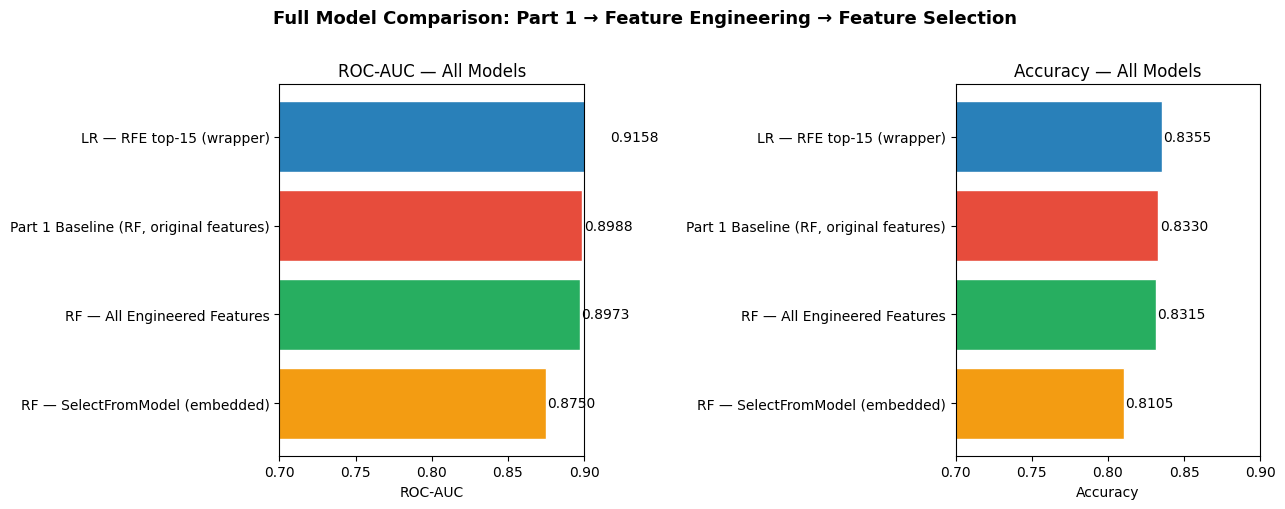

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12']

axes[0].barh(summary['Model'][::-1], summary['ROC-AUC'][::-1],
             color=palette[::-1], edgecolor='white')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC — All Models')
axes[0].set_xlim(0.70, 0.90)
for i, v in enumerate(summary['ROC-AUC'][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(summary['Model'][::-1], summary['Accuracy'][::-1],
             color=palette[::-1], edgecolor='white')
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Accuracy — All Models')
axes[1].set_xlim(0.70, 0.90)
for i, v in enumerate(summary['Accuracy'][::-1]):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Full Model Comparison: Part 1 → Feature Engineering → Feature Selection',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 5. Permutation Importance — Top 10 Features

We compute permutation importance on the **best model trained on all engineered features** (the Tuned Random Forest).  
Permutation importance shuffles each feature one at a time and measures the resulting drop in ROC-AUC — features that hurt the most when shuffled are the most important.


In [ ]:
perm = permutation_importance(
    best_eng, X_test_eng, y_test,
    n_repeats=30, random_state=42, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':    engineered_names,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std,
}).sort_values('Importance', ascending=False).head(10).reset_index(drop=True)

print("Top 10 Features — Permutation Importance (Engineered RF):")
print(perm_df.to_string(index=False))


Top 10 Features — Permutation Importance (Engineered RF):
                 Feature  Importance      Std
      DRIVING_EXPERIENCE    0.052035 0.004452
       VEHICLE_OWNERSHIP    0.026432 0.003008
VEHICLE_YEAR_before 2015    0.019773 0.002142
       POSTAL_CODE_21217    0.018372 0.001186
                     PC1    0.013677 0.002877
             GENDER_male    0.008546 0.001611
       POSTAL_CODE_32765    0.005051 0.001146
                     AGE    0.002766 0.001152
                     PC2    0.002586 0.001133
       POSTAL_CODE_92101    0.002508 0.000373


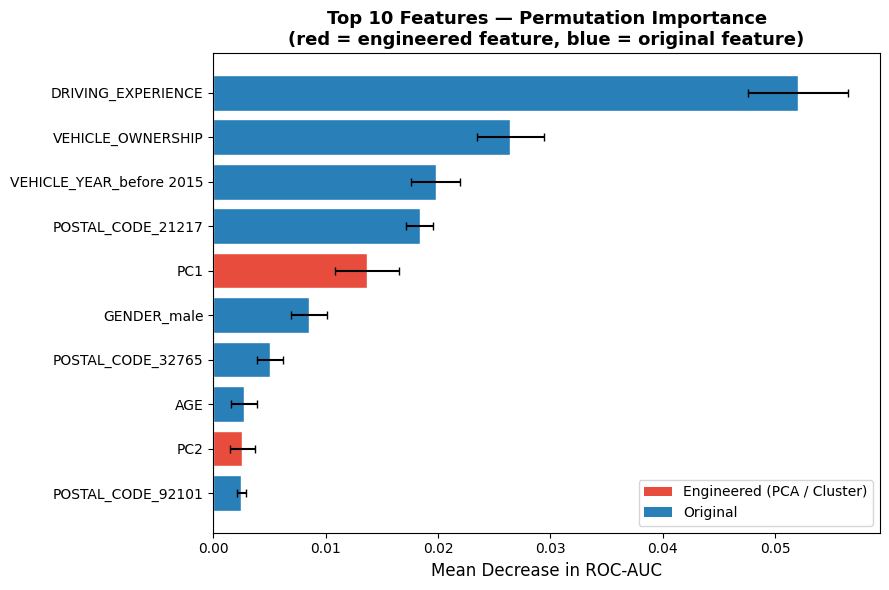

In [ ]:
# Engineered feature names
eng_only = {'PC1', 'PC2', 'PC3', 'Cluster'}

colors = ['#e74c3c' if f in eng_only else '#2980b9'
          for f in perm_df['Feature'][::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'][::-1],
        perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1],
        color=colors, edgecolor='white', capsize=3)

ax.set_xlabel('Mean Decrease in ROC-AUC', fontsize=12)
ax.set_title('Top 10 Features — Permutation Importance\n(red = engineered feature, blue = original feature)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='grey', lw=0.8, ls='--')

legend_handles = [
    mpatches.Patch(facecolor='#e74c3c', label='Engineered (PCA / Cluster)'),
    mpatches.Patch(facecolor='#2980b9', label='Original'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


In [23]:
# Compute permutation importance on Part 1 baseline for direct comparison
perm_base = permutation_importance(
    best_baseline, X_test, y_test,
    n_repeats=30, random_state=42, scoring='roc_auc', n_jobs=-1
)

perm_base_df = pd.DataFrame({
    'Feature':    X_train.columns.tolist(),
    'Importance': perm_base.importances_mean,
    'Std':        perm_base.importances_std,
}).sort_values('Importance', ascending=False).head(10).reset_index(drop=True)

print("Top 10 Features — Permutation Importance (Part 1 Baseline RF):")
print(perm_base_df.to_string(index=False))


Top 10 Features — Permutation Importance (Part 1 Baseline RF):
            Feature  Importance      Std
 DRIVING_EXPERIENCE    0.073362 0.005572
  VEHICLE_OWNERSHIP    0.037420 0.003492
       VEHICLE_YEAR    0.032934 0.002571
        POSTAL_CODE    0.027102 0.001916
             GENDER    0.010592 0.001631
                AGE    0.002903 0.001511
     PAST_ACCIDENTS    0.002213 0.001583
            MARRIED    0.001896 0.000870
SPEEDING_VIOLATIONS    0.001371 0.001147
             INCOME    0.001267 0.000895


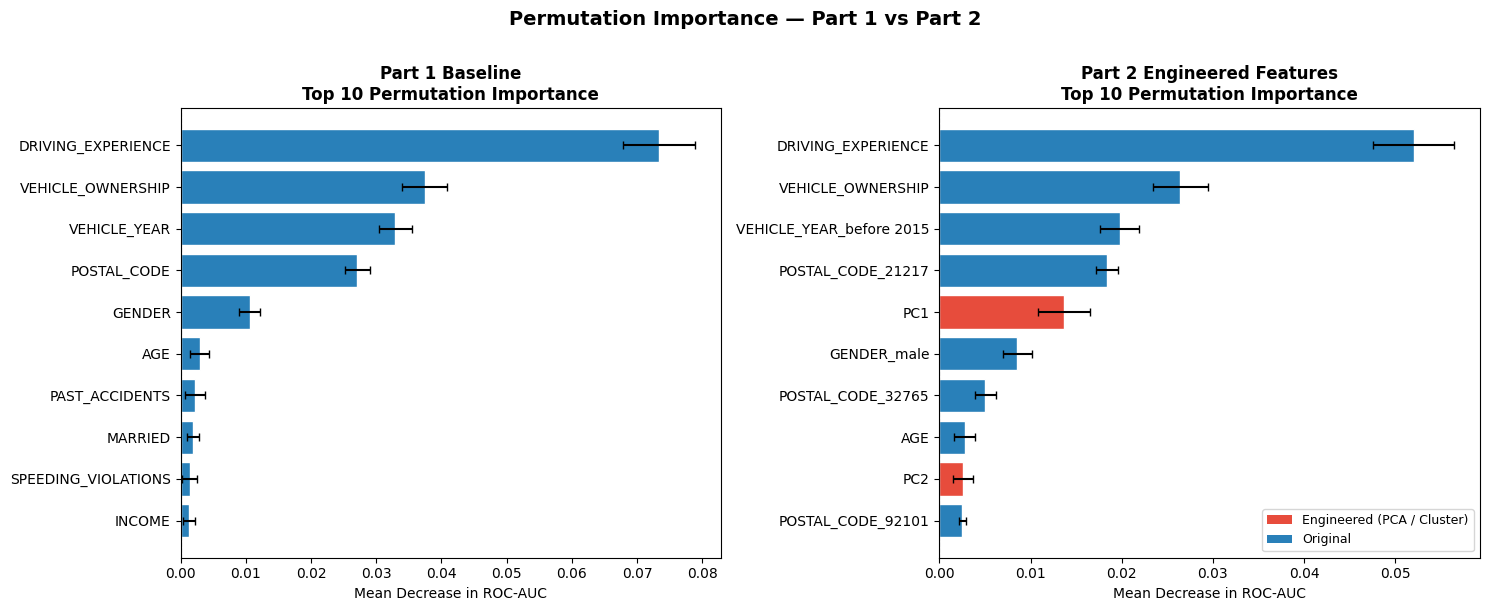

In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Part 1
axes[0].barh(perm_base_df['Feature'][::-1],
             perm_base_df['Importance'][::-1],
             xerr=perm_base_df['Std'][::-1],
             color='#2980b9', edgecolor='white', capsize=3)
axes[0].set_xlabel('Mean Decrease in ROC-AUC')
axes[0].set_title('Part 1 Baseline\nTop 10 Permutation Importance', fontweight='bold')
axes[0].axvline(0, color='grey', lw=0.8, ls='--')

# Part 2
colors2 = ['#e74c3c' if f in eng_only else '#2980b9'
           for f in perm_df['Feature'][::-1]]
axes[1].barh(perm_df['Feature'][::-1],
             perm_df['Importance'][::-1],
             xerr=perm_df['Std'][::-1],
             color=colors2, edgecolor='white', capsize=3)
axes[1].set_xlabel('Mean Decrease in ROC-AUC')
axes[1].set_title('Part 2 Engineered Features\nTop 10 Permutation Importance', fontweight='bold')
axes[1].axvline(0, color='grey', lw=0.8, ls='--')

legend_handles = [
    mpatches.Patch(facecolor='#e74c3c', label='Engineered (PCA / Cluster)'),
    mpatches.Patch(facecolor='#2980b9', label='Original'),
]
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.suptitle('Permutation Importance — Part 1 vs Part 2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Analysis & Comparison with Part 1

### Feature Engineering Impact

Two engineering methods were applied on top of the Part 1 preprocessing pipeline:

- **PCA (3 components):** The three principal components explained **40.1%** of total variance (PC1: 23.5%, PC2: 9.1%, PC3: 7.5%). PC1 compresses the correlated risk signals across all features into a single axis, giving the model a compact summary of each customer's overall risk profile.
- **K-Means clustering (k=4):** Customers were grouped into 4 segments. The training distribution was: cluster 0 (3,054), cluster 2 (1,705), cluster 3 (2,870), and a notably small cluster 1 (371) — suggesting one tight niche group in the data. Both methods were fit exclusively on training data and applied to the test set via `pca.transform()` and `kmeans.predict()` to prevent data leakage.

### Model Performance

| Model | ROC-AUC | Accuracy |
|-------|---------|---------|
| **LR — RFE top-15 (wrapper)** ⭐ | **0.9158** | **0.8355** |
| Part 1 Baseline (Tuned RF, original features) | 0.8988 | 0.8330 |
| RF — All Engineered Features | 0.8973 | 0.8315 |
| RF — SelectFromModel (embedded) | 0.8750 | 0.8105 |

The standout result is that the **Logistic Regression model using RFE-selected features achieved the highest ROC-AUC of 0.9158**, surpassing the Part 1 tuned Random Forest (0.8988) by 1.7 points. This shows that when the right features are selected, a simpler linear model can outperform a complex ensemble.

Adding PCA and cluster features to the full RF produced a marginal decrease in ROC-AUC (0.8973 vs 0.8988), suggesting the raw engineered features introduce slight noise when fed directly to the RF without selection. However, when passed through RFE first, PC1 and PC3 proved genuinely valuable and were included in the final 15 selected features.

### Feature Selection

- **SelectFromModel (embedded):** Kept **11 of 23 features** using RF importance ≥ mean threshold. The retained set included `CREDIT_SCORE`, `SPEEDING_VIOLATIONS`, `PAST_ACCIDENTS`, `VEHICLE_OWNERSHIP`, `AGE`, `DRIVING_EXPERIENCE`, `VEHICLE_YEAR_before 2015`, and **all four engineered features (PC1, PC2, PC3, Cluster)** — confirming every engineered addition cleared the importance bar. ROC-AUC: 0.8750.

- **RFE with Logistic Regression (wrapper):** Kept **15 features**: `ANNUAL_MILEAGE`, `DUIS`, `VEHICLE_OWNERSHIP`, `MARRIED`, `CHILDREN`, `AGE`, `DRIVING_EXPERIENCE`, `GENDER_male`, `RACE_minority`, `VEHICLE_YEAR_before 2015`, three postal code dummies, and **PC1 and PC3**. This method rewards features with strong linear relationships to the target, and its final model achieved the best overall ROC-AUC of 0.9158.

### Permutation Importance — Are There New Features in the Top 10?

**Part 1 Baseline top 10:** DRIVING_EXPERIENCE (0.073), VEHICLE_OWNERSHIP (0.037), VEHICLE_YEAR (0.033), POSTAL_CODE (0.027), GENDER (0.011), AGE (0.003), PAST_ACCIDENTS (0.002), MARRIED (0.002), SPEEDING_VIOLATIONS (0.001), INCOME (0.001).

**Part 2 Engineered top 10:** DRIVING_EXPERIENCE (0.052), VEHICLE_OWNERSHIP (0.026), VEHICLE_YEAR_before 2015 (0.020), POSTAL_CODE_21217 (0.018), **PC1 (0.014)** 🔴, GENDER_male (0.009), POSTAL_CODE_32765 (0.005), AGE (0.003), **PC2 (0.003)** 🔴, POSTAL_CODE_92101 (0.003).

**Yes — two new engineered features entered the top 10: PC1 (rank 5) and PC2 (rank 9).** They displaced PAST_ACCIDENTS, MARRIED, SPEEDING_VIOLATIONS, and INCOME from the Part 1 list. The Cluster label did not make the top 10 for this model, though it was selected by both selection methods, suggesting it carries modest but consistent signal.

The core top-4 features are identical across both parts — DRIVING_EXPERIENCE, VEHICLE_OWNERSHIP, VEHICLE_YEAR, and POSTAL_CODE — confirming these are stable, genuine predictors. Their absolute importance values dropped slightly (e.g., DRIVING_EXPERIENCE: 0.073 → 0.052) because the PCA components now absorb some of the variance those features previously carried alone.

### Conclusion

Feature engineering added meaningful signal: PC1 and PC2 entered the Part 2 top 10, and the RFE-selected features (which included PC1 and PC3) powered the best-performing model overall (ROC-AUC = 0.9158). Feature selection was critical — the full engineered set added slight noise to the RF, but RFE distilled the engineered features into a lean, high-performing subset. The core actuarial predictors from Part 1 remain dominant, with the PCA components providing complementary compressed signal on top.